In [26]:
from collections import defaultdict
import json
import math

# Load data
with open('step_stats_5.json') as f:
    data = json.load(f)
with open('randla_stats_5.json') as f2:
    data2 = json.load(f2)

with open('combine_stats_5.json') as f3:
    data3 = json.load(f3)
def euclidean(p1, p2):
    """Simple 2D Euclidean distance"""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def process_data(data):
    groups = defaultdict(list)
    for entry in data:
        start = tuple(round(x) for x in entry["start_point"])
        goal = tuple(round(x) for x in entry["goal_point"])
        key = (start, goal)
        groups[key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # New: distances involving current_pos
        dist_start_curr = [euclidean(entry["start_point"], entry["current_pos"]) for entry in group]
        dist_curr_goal = [euclidean(entry["current_pos"], entry["goal_point"]) for entry in group]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)

        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  # percent
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal
        }
    return stats

# Process both datasets
stats1 = process_data(data)
stats2 = process_data(data2)
stats3 = process_data(data3)
# Example printout for dataset 2
for key, values in stats2.items():
    print(f"Group {key}:")
    for stat_name, stat_value in values.items():
        if stat_name == "reach_goal_rate":
            print(f"  {stat_name}: {stat_value:.2f}%")
        else:
            print(f"  {stat_name}: {stat_value:.4f}")
    print()


Group ((-30, 7), (-22, 17)):
  total_length: 22.5065
  dist_togoal: 13.1244
  collision_count: 44.1500
  count: 128.7500
  reach_goal_rate: 90.00%
  dist_start_to_current: 12.7875
  dist_current_to_goal: 1.4938

Group ((-30, -20), (-22, -6)):
  total_length: 36.1389
  dist_togoal: 16.3438
  collision_count: 16.6000
  count: 178.7500
  reach_goal_rate: 90.00%
  dist_start_to_current: 16.3112
  dist_current_to_goal: 1.1066

Group ((-31, -44), (-20, -37)):
  total_length: 59.6262
  dist_togoal: 13.0384
  collision_count: 74.2000
  count: 269.5500
  reach_goal_rate: 55.00%
  dist_start_to_current: 17.0550
  dist_current_to_goal: 5.4882

Group ((-55, 5), (-41, 5)):
  total_length: 47.1721
  dist_togoal: 14.0000
  collision_count: 131.7500
  count: 282.4000
  reach_goal_rate: 45.00%
  dist_start_to_current: 12.6623
  dist_current_to_goal: 2.1688

Group ((-33, 40), (-20, 40)):
  total_length: 92.6066
  dist_togoal: 13.0000
  collision_count: 14.7000
  count: 350.0000
  reach_goal_rate: 0.00%


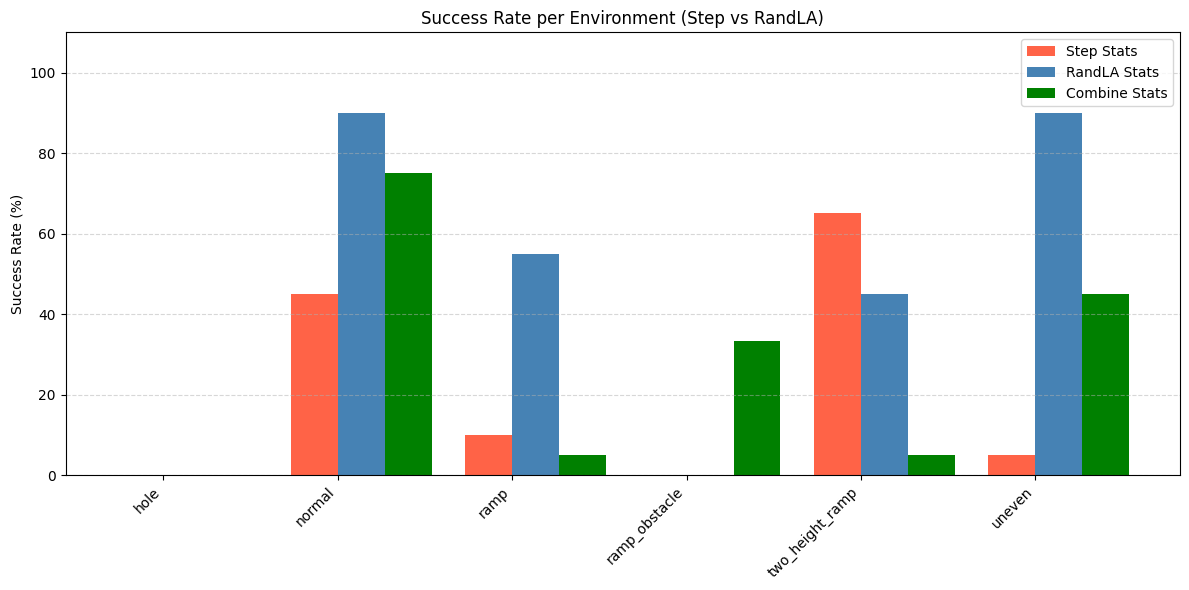

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Environment mapping (same as before)
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Convert stats1/stats2 keys from coordinates to labels
def relabel_stats(stats):
    new_stats = {}
    for (start, goal), values in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        new_stats[label] = values
    return new_stats

stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
# Combine all labels
all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

step_rates = [stats1_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
randla_rates = [stats2_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
combine_rates = [stats3_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
x = np.arange(len(all_labels)) * 1.3  # widen spacing between groups

width = 0.35

plt.figure(figsize=(max(12, len(all_labels)*0.6), 6))
plt.bar(x - width/2, step_rates, width, label='Step Stats', color='tomato')
plt.bar(x + width/2, randla_rates, width, label='RandLA Stats', color='steelblue')
plt.bar(x + width*1.5, combine_rates, width, label='Combine Stats', color='green')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Success Rate (%)")
plt.ylim(0, 110)
plt.title("Success Rate per Environment (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Reuse relabelled stats ---
# stats1_labeled = relabel_stats(stats1)
# stats2_labeled = relabel_stats(stats2)
# stats3_labeled = relabel_stats(stats3)
# all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

# # Extract values
# step_start_curr    = [stats1_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# randla_start_curr  = [stats2_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# combine_start_curr = [stats3_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]

# step_curr_goal     = [stats1_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# randla_curr_goal   = [stats2_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# combine_curr_goal  = [stats3_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]

# # Centers for each group (add spacing between groups)
# x = np.arange(len(all_labels)) * 1.6

# # Bar geometry: 6 bars per group, symmetric offsets around center
# width = 0.18
# offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# plt.figure(figsize=(max(14, len(all_labels)*0.9), 6))

# # Step (solid + hatched)
# plt.bar(x + offsets[0], step_start_curr, width, label='Step: Start→Current', color='tomato')
# plt.bar(x + offsets[1], step_curr_goal,  width, label='Step: Current→Goal', color='tomato',
#         hatch='//', edgecolor='black')

# # RandLA (solid + hatched)
# plt.bar(x + offsets[2], randla_start_curr, width, label='RandLA: Start→Current', color='steelblue')
# plt.bar(x + offsets[3], randla_curr_goal,  width, label='RandLA: Current→Goal', color='steelblue',
#         hatch='\\\\', edgecolor='black')

# # Combine (solid + hatched)
# plt.bar(x + offsets[4], combine_start_curr, width, label='Combine: Start→Current', color='green')
# plt.bar(x + offsets[5], combine_curr_goal,  width, label='Combine: Current→Goal', color='green',
#         hatch='xx', edgecolor='black')

# plt.xticks(x, all_labels, rotation=45, ha='right')
# plt.ylabel("Mean Distance")
# plt.title("Mean Distances per Environment (Step vs RandLA)")
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# # Keep legend compact
# plt.legend(ncol=3, frameon=True)
# plt.tight_layout()
# plt.show()


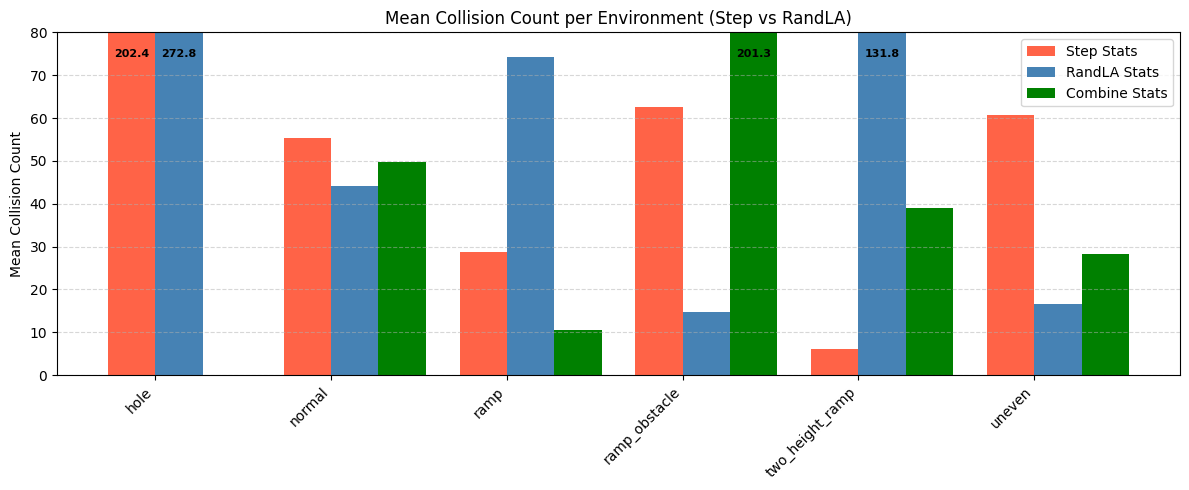

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Map from (rounded_start, rounded_goal) -> label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    """Convert {(start, goal): metrics} -> {label: metrics} using env_map.
       Falls back to 'start→goal' string if a pair isn't in env_map."""
    out = {}
    for (start, goal), vals in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        out[label] = vals
    return out

stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
# Combine labels (instead of coordinate pairs)
all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

step_collision_means = [stats1_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
randla_collision_means = [stats2_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
combine_collision_means = [stats3_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
x = np.arange(len(all_labels)) * 1.3  # widen spacing between groups
width = 0.35

plt.figure(figsize=(max(12, len(all_labels)*0.6), 5))
bars1 = plt.bar(x - width/2, step_collision_means, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_collision_means, width, label='RandLA Stats', color='steelblue')
bars3 = plt.bar(x + width*1.5, combine_collision_means, width, label='Combine Stats', color='green')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Collision Count per Environment (Step vs RandLA)")
plt.legend()

ylim_val = 80
plt.ylim(0, ylim_val)  # Fixed y-limit

plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

def label_only_over_limit(bars, limit=ylim_val, label_y=75):
    for bar in bars:
        height = bar.get_height()
        if height > limit:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{height:.1f}',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='black'
            )

label_only_over_limit(bars1)
label_only_over_limit(bars2)
label_only_over_limit(bars3)

plt.show()


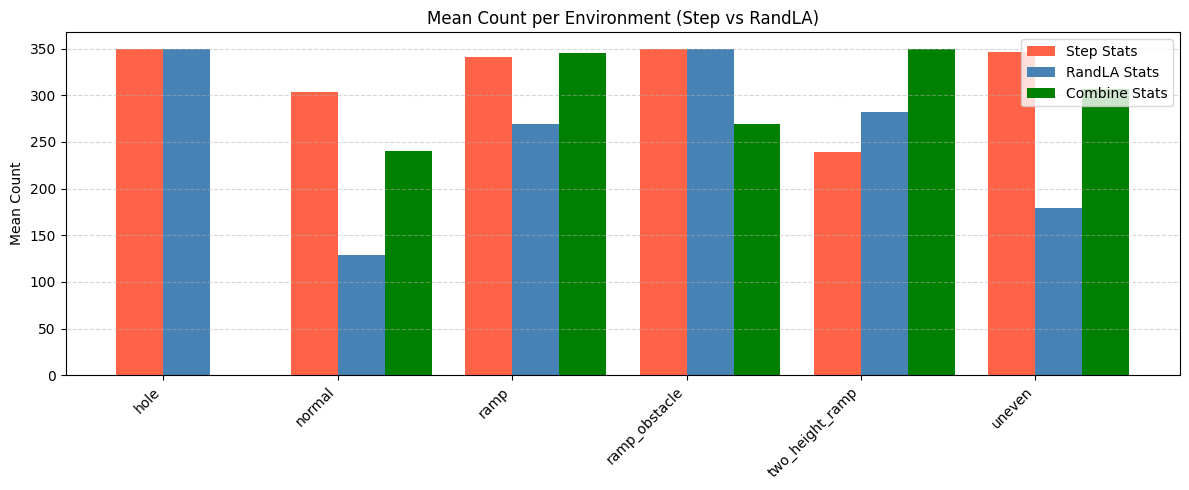

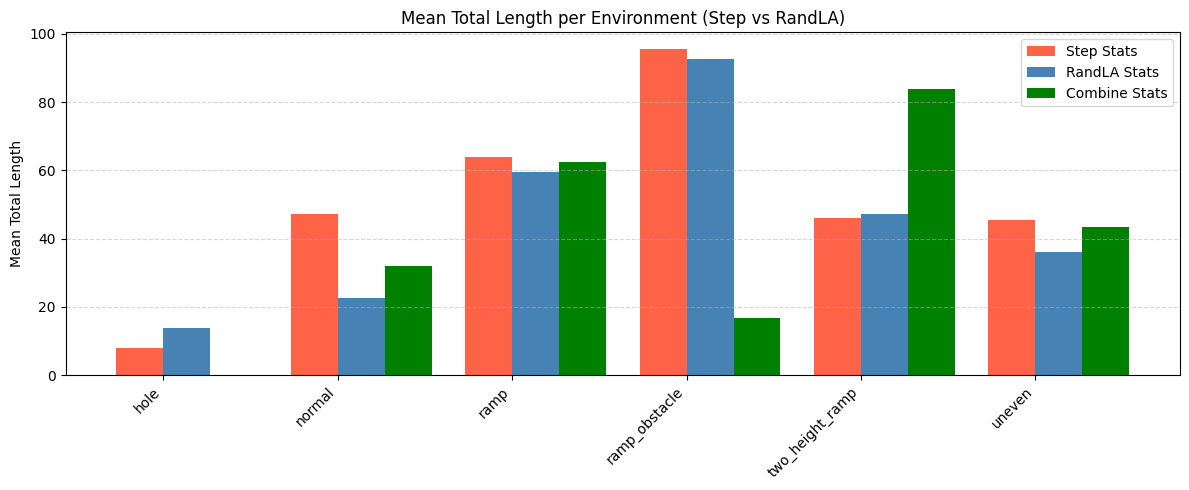

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping from (rounded start, rounded goal) -> environment label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    """Convert {(start, goal): metrics} -> {label: metrics} using env_map.
       Falls back to 'start→goal' string if pair is not in env_map."""
    out = {}
    for (start, goal), vals in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        out[label] = vals
    return out

# Apply relabeling
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
# Collect all labels (instead of coordinates)
all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

step_counts = [stats1_labeled.get(label, {}).get("count", 0) for label in all_labels]
randla_counts = [stats2_labeled.get(label, {}).get("count", 0) for label in all_labels]
combine_counts = [stats3_labeled.get(label, {}).get("count", 0) for label in all_labels]

step_lengths = [stats1_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
randla_lengths = [stats2_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
combine_lengths = [stats3_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
width = 0.25  # smaller bar width
x = np.arange(len(all_labels)) * 1.3  # widen spacing between groups

width = 0.35

# --- Plot Mean Count comparison ---
plt.figure(figsize=(max(12, len(all_labels)*0.6), 5))
bars1 = plt.bar(x - width/2, step_counts, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_counts, width, label='RandLA Stats', color='steelblue')
bars3 = plt.bar(x + width*1.5, combine_counts, width, label='Combine Stats', color='green')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Count")
plt.title("Mean Count per Environment (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Plot Mean Total Length comparison ---
plt.figure(figsize=(max(12, len(all_labels)*0.6), 5))
bars1 = plt.bar(x - width/2, step_lengths, width, label='Step Stats', color='tomato')
bars2 = plt.bar(x + width/2, randla_lengths, width, label='RandLA Stats', color='steelblue')
bars3 = plt.bar(x + width*1.5, combine_lengths, width, label='Combine Stats', color='green')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Total Length")
plt.title("Mean Total Length per Environment (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
